# Intervenciones (do-operator) sobre el SCM triangulo

Extiende el notebook `Ruido_ Aditivo_Gausiano_media.ipynb` (pasos 1 y 2) con el **paso 3**: muestreo
interventional `P(Z | do(Y=1))` para cada peso `beta` (peso de HSIC), validado contra el SCM verdadero.
Grafo: X -> Y, X -> Z, Y -> Z. Solo histogramas (sin KDE, sin ATE).

La celda 1 entrena los 11 modelos una sola vez y los cachea en `modelos/`; las ejecuciones posteriores
los cargan del disco (no reentrenan) mientras no cambien `SEED` ni `N`.

In [1]:
# ============================================================
# CELDA 1 - Setup + entrenamiento de un modelo por beta (peso HSIC)
# Reutiliza el SCM, el grafo y la configuracion del notebook de referencia,
# pero entrena UN modelo por cada uno de los 11 valores de beta.
# ============================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.models.kan import kan_model_mixed


# SCM de referencia (triangulo, ruido aditivo gaussiano)
def generate_synthetic_triangle_data_pure_gausian(num_samples=2000, seed=42, escala=1.0):
    # Genera el SCM no lineal con ruido gaussiano (media 0, desviacion = escala)
    np.random.seed(seed)
    eps_X = np.random.normal(loc=0.0, scale=escala, size=num_samples)
    eps_Y = np.random.normal(loc=0.0, scale=escala, size=num_samples)
    eps_Z = np.random.normal(loc=0.0, scale=escala, size=num_samples)

    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})


def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    # Empaqueta la configuracion de pesos por nodo que requiere kan_model_mixed
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos


# Configuracion del experimento
SEED = 42
N = 2000  # mas muestras que el notebook base para histogramas interventionales limpios

graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0,
}

# Datos: un unico split train/eval
data = generate_synthetic_triangle_data_pure_gausian(num_samples=N, seed=SEED, escala=1.0)
factual_train_d, factual_eval_d = train_test_split(data, test_size=0.5, random_state=42)

# 11 configuraciones de perdida: beta = 1 - alpha
configs = [('mse', 1.0, 0.0), ('hsic', 0.0, 1.0)]
configs += [('hybrid', round(a, 2), round(1.0 - a, 2))
            for a in np.linspace(0.0, 1.0, num=11) if a not in (0.0, 1.0)]


print('Entrenando 11 modelos (uno por beta)...')
models = {}
for loss_name, alpha, beta in configs:
    print('Entrenando loss=' + loss_name + '  alpha=' + str(alpha) + '  beta=' + str(beta) + ' ...')
    params = crear_estructura_nodos(graph_triangle, base_kan_params, loss_name, alpha, beta, node_types, num_classes)
    modelo = kan_model_mixed(graph_triangle, params)
    modelo.fit(data=factual_train_d)
    models[beta] = modelo


print('Modelos disponibles (uno por beta): ' + str(sorted(models)))

Entrenando 11 modelos (uno por beta)...
Entrenando loss=mse  alpha=1.0  beta=0.0 ...
Using device: cpu
Early stopping at step 316
Using device: cpu
Early stopping at step 452
Entrenando loss=hsic  alpha=0.0  beta=1.0 ...
Using device: cpu
Early stopping at step 266
Using device: cpu
Early stopping at step 99
Entrenando loss=hybrid  alpha=0.1  beta=0.9 ...
Using device: cpu
Early stopping at step 401
Using device: cpu
Early stopping at step 405
Entrenando loss=hybrid  alpha=0.2  beta=0.8 ...
Using device: cpu
Early stopping at step 234
Using device: cpu
Early stopping at step 143
Entrenando loss=hybrid  alpha=0.3  beta=0.7 ...
Using device: cpu
Early stopping at step 251
Using device: cpu
Early stopping at step 451
Entrenando loss=hybrid  alpha=0.4  beta=0.6 ...
Using device: cpu
Early stopping at step 285
Using device: cpu
Early stopping at step 186
Entrenando loss=hybrid  alpha=0.5  beta=0.5 ...
Using device: cpu
Early stopping at step 299
Using device: cpu
Early stopping at step 429


In [2]:
# ============================================================
# CELDA 2 - Oraculo: generador interventional del SCM verdadero
# Muta el SCM verdadero para poder validar las muestras del modelo.
# ============================================================
def gt_interventional(node, value, n, seed):
    # Muestras del SCM VERDADERO bajo do(node = value)
    rng = np.random.default_rng(seed)
    eX = rng.normal(size=n)
    eY = rng.normal(size=n)
    eZ = rng.normal(size=n)
    X = np.full(n, value) if node == 'X' else eX
    Y = np.full(n, value) if node == 'Y' else 0.5 * X ** 2 + np.sin(X) + eY
    Z = 0.7 * X + 0.4 * Y ** 2 - np.cos(Y) + eZ
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

In [3]:
# ============================================================
# CELDA 3 - Muestreo interventional del modelo (do-operator) + demostracion
# ============================================================
def model_intervention(model, node, value, n, seed=42):
    # Muestras del MODELO KAN bajo do(node = value).
    # La lambda captura el valor con un argumento por defecto (v=value); un cierre
    # libre haria que en un bucle todas las intervenciones colapsen al ultimo valor.
    intervention = {node: (lambda _, v=value: v)}
    muestras = model.interventional_samples(intervention, num_samples_to_draw=n, seed=seed)
    return muestras[['X', 'Y', 'Z']]


# Demostracion: do(Y = 1) sobre el modelo MSE (beta = 0.0)
demo = model_intervention(models[0.0], 'Y', 1.0, n=2000, seed=42)
print('Muestras interventionales del modelo bajo do(Y=1)  (beta=0.0):')
print(demo.describe())

Muestras interventionales del modelo bajo do(Y=1)  (beta=0.0):
                 X       Y            Z
count  2000.000000  2000.0  2000.000000
mean      0.046515     1.0    -0.089934
std       0.973412     0.0     1.189587
min      -3.189788     1.0    -3.808799
25%      -0.611062     1.0    -0.898119
50%       0.046129     1.0    -0.085305
75%       0.674694     1.0     0.708693
max       3.796175     1.0     5.959397


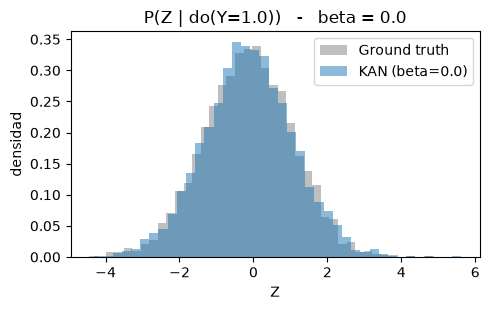

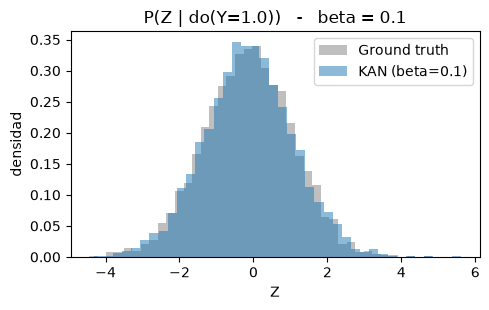

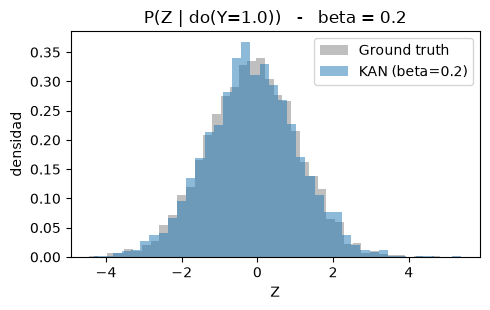

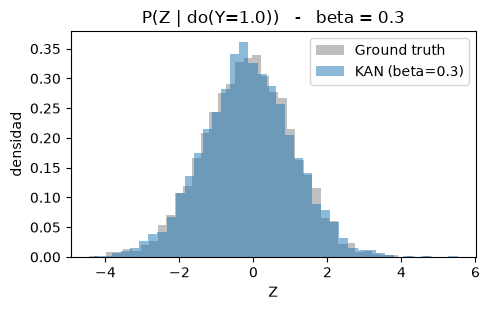

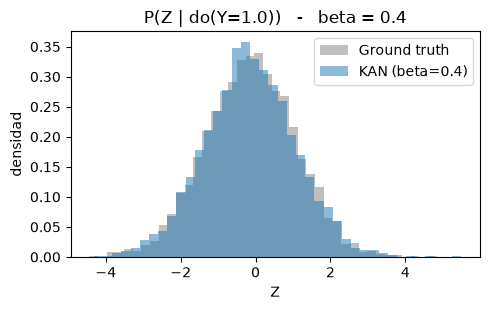

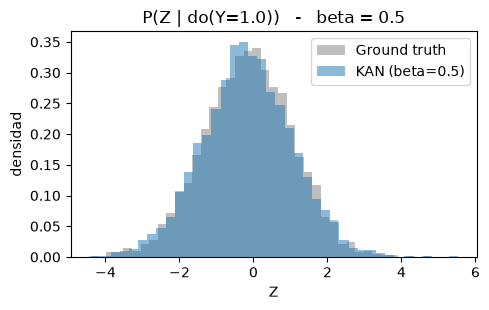

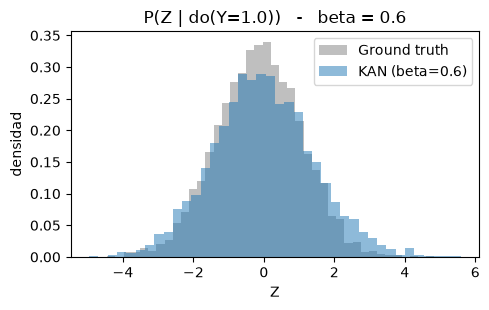

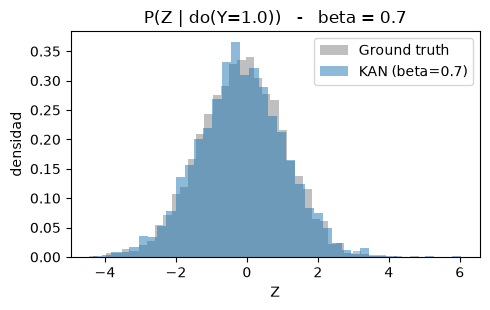

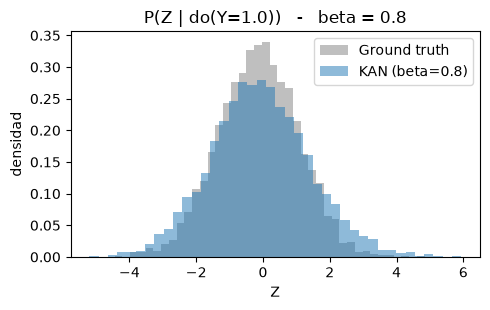

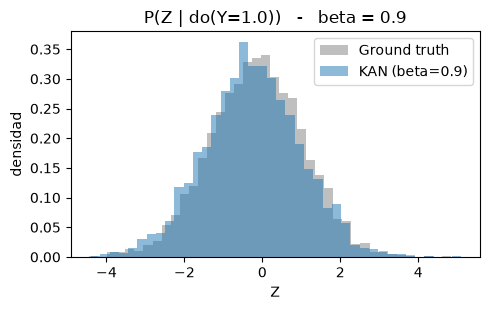

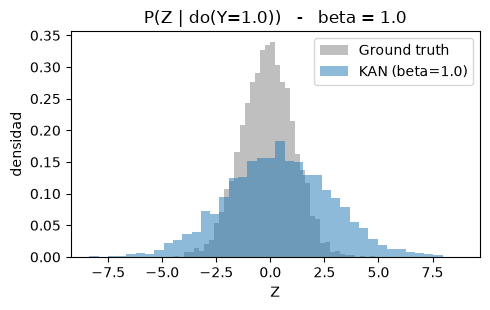

In [4]:
# ============================================================
# CELDA 4 - HEADLINE: P(Z | do(Y=1)) por cada beta (11 histogramas)
# Cada figura superpone modelo KAN vs SCM verdadero (ground truth).
# Solo histogramas: sin KDE, sin ATE. Un figura por beta => 11 plots.
# ============================================================
Y_DO = 1.0
n = 4000

z_gt = gt_interventional('Y', Y_DO, n, seed=0)['Z']

for beta in sorted(models):
    z_model = model_intervention(models[beta], 'Y', Y_DO, n, seed=42)['Z']

    fig, ax = plt.subplots(figsize=(5, 3.2))
    ax.hist(z_gt, bins=40, density=True, alpha=0.5, color='gray', label='Ground truth')
    ax.hist(z_model, bins=40, density=True, alpha=0.5, color='tab:blue', label='KAN (beta=' + str(beta) + ')')
    ax.set_xlabel('Z')
    ax.set_ylabel('densidad')
    ax.set_title('P(Z | do(Y=' + str(Y_DO) + '))   -   beta = ' + str(beta))
    ax.legend()
    plt.tight_layout()
    plt.show()